In [4]:
import pickle
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import networkx as nx
import pyproj
import geopandas as gpd
import shapely
from shapely import Polygon, Point, LineString

from shapely.ops import transform
from pyproj import Transformer

from tqdm.auto import tqdm

from pathlib import Path

In [5]:
src_dir = Path('~').expanduser() / 'data/d-osp/gtsm'

In [8]:
ds = xr.open_dataset(src_dir / 'filtered-currents.nc')
ds = ds.isel(time=8)

In [10]:
node_geoms = gpd.points_from_xy(ds['Mesh_face_x'], ds['Mesh_face_y'])
node_gdf = gpd.GeoDataFrame({'currents_u': ds['currents_u'], 'currents_v': ds['currents_v'], 'geometry': node_geoms})
node_gdf

,currents_u,currents_v,geometry
0,0.000,-0.001,POINT (7.33154 53.31299)
1,0.000,-0.001,POINT (7.33154 53.29834)
2,0.000,0.003,POINT (7.34619 53.31299)
3,0.000,0.003,POINT (7.34619 53.29834)
4,0.000,0.000,POINT (7.36084 53.31299)
...,...,...,...
19596,-0.437,-0.828,POINT (1.65527 51.22559)
19597,-0.458,-1.023,POINT (1.60669 51.22611)
19598,-0.409,-0.902,POINT (1.62598 51.22559)
19599,-0.552,-0.845,POINT (1.65527 51.19629)


In [11]:
def get_neighbors(ds, face_id):
    Mesh_face_nodes = ds['Mesh_face_nodes'].values - 1
    face_nodes = Mesh_face_nodes[face_id, :]
    face_nodes = face_nodes[~np.isnan(face_nodes)]
    face_nodes = face_nodes[face_nodes != -2]

    # Build node-to-face mapping
    node_to_faces = {}
    for f_id, nodes in enumerate(Mesh_face_nodes):
        valid_nodes = nodes[~np.isnan(nodes)]
        for node in valid_nodes:
            node_to_faces.setdefault(node, set()).add(f_id)

    # Collect neighbors
    neighbors = set()
    for node in face_nodes:
        neighbors.update(node_to_faces[node])

    neighbors.discard(face_id)
    return sorted(neighbors)

# Example usage
face_id = 2
adjacent_faces = get_neighbors(ds, face_id)


<Axes: >

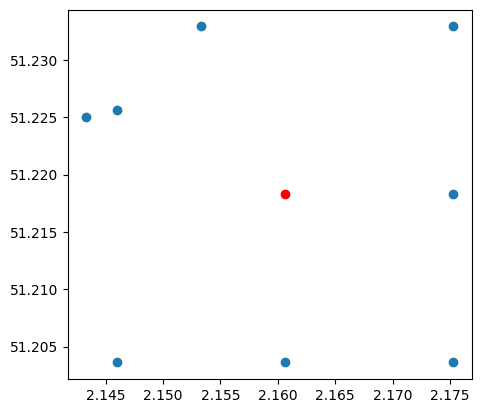

In [12]:
i = 19090
fig, ax = plt.subplots()
node_gdf.iloc[get_neighbors(ds, i)].plot(ax=ax)
node_gdf.iloc[[i]].plot(ax=ax, color='red')

In [13]:
edge_gdf = {'source': [], 'target': [], 'currents_u': [], 'currents_v': [], 'geometry': []}
for idx, node in tqdm(node_gdf.iterrows(), total=len(node_gdf)):
    source_node = idx
    target_nodes = get_neighbors(ds, source_node)
    for target_node in target_nodes:
        if target_node in edge_gdf['source']:
            continue
        geometry = LineString([node_gdf.iloc[source_node]['geometry'], node_gdf.iloc[target_node]['geometry']])
        currents_u = np.mean([node_gdf.iloc[source_node]['currents_u'], node_gdf.iloc[target_node]['currents_u']])
        currents_v = np.mean([node_gdf.iloc[source_node]['currents_v'], node_gdf.iloc[target_node]['currents_v']])
        
        edge_gdf['source'].append(source_node)
        edge_gdf['target'].append(target_node)
        edge_gdf['currents_u'].append(currents_u)
        edge_gdf['currents_v'].append(currents_v)
        edge_gdf['geometry'].append(geometry)

edge_gdf = gpd.GeoDataFrame(edge_gdf)
edge_gdf = edge_gdf.set_crs('EPSG:4326')

  0%|          | 0/19601 [00:00<?, ?it/s]

In [14]:
edge_gdf

,source,target,currents_u,currents_v,geometry
0,0,1,0.0000,-0.0010,"LINESTRING (7.33154 53.31299, 7.33154 53.29834)"
1,0,2,0.0000,0.0010,"LINESTRING (7.33154 53.31299, 7.34619 53.31299)"
2,0,3,0.0000,0.0010,"LINESTRING (7.33154 53.31299, 7.34619 53.29834)"
3,1,2,0.0000,0.0010,"LINESTRING (7.33154 53.29834, 7.34619 53.31299)"
4,1,3,0.0000,0.0010,"LINESTRING (7.33154 53.29834, 7.34619 53.29834)"
...,...,...,...,...,...
76944,19589,19590,-0.6450,-0.7225,"LINESTRING (1.74316 51.16699, 1.71387 51.19629)"
76945,19590,19595,-0.5920,-0.7505,"LINESTRING (1.71387 51.19629, 1.68457 51.19629)"
76946,19591,19592,-0.4145,-0.7730,"LINESTRING (1.65527 51.25488, 1.68457 51.22559)"
76947,19591,19596,-0.4000,-0.8045,"LINESTRING (1.65527 51.25488, 1.65527 51.22559)"


In [15]:
edge_gdf = edge_gdf.to_crs('EPSG:3035')
edge_gdf['length'] = shapely.length(edge_gdf['geometry'])

In [9]:
edge_gdf.to_file(src_dir / 'edge-gdf.gpkg')

In [16]:
G = nx.from_pandas_edgelist(edge_gdf, edge_attr=True)

In [17]:
# nodes_df_indexed = node_gdf.set_index('node_id')

# 2. Convert the dataframe to a dictionary of dictionaries
# Format: {node_id: {'attr1': val1, 'attr2': val2}}
node_gdf = gpd.GeoDataFrame({'currents_u': ds['currents_u'], 'currents_v': ds['currents_v'], 'geometry': node_geoms})
node_gdf = node_gdf.set_crs("EPSG:4326")
node_gdf = node_gdf.to_crs("EPSG:3035")
node_attributes = node_gdf.to_dict('index')

# 3. Apply the attributes to the graph
nx.set_node_attributes(G, node_attributes)

In [18]:
from sklearn.cluster import KMeans
def coarsen_mesh_spatial(G, target_clusters):
    # Extract coordinates
    coords = np.array([[G.nodes[n]['geometry'].x, G.nodes[n]['geometry'].y] for n in G.nodes()])
    node_ids = list(G.nodes())

    # Cluster nodes using KMeans
    kmeans = KMeans(n_clusters=target_clusters, random_state=42)
    labels = kmeans.fit_predict(coords)

    # Create new graph
    H = nx.Graph()

    # Add super-nodes with averaged coordinates
    for cluster_id in range(target_clusters):
        cluster_nodes = [node_ids[i] for i in range(len(node_ids)) if labels[i] == cluster_id]
        avg_x = np.mean([G.nodes[n]['geometry'].x for n in cluster_nodes])
        avg_y = np.mean([G.nodes[n]['geometry'].y for n in cluster_nodes])
        H.add_node(cluster_id, x=avg_x, y=avg_y, members=cluster_nodes)

    # Build edges between clusters and average attributes
    edge_dict = {}
    for u, v, data in G.edges(data=True):
        cu = labels[node_ids.index(u)]
        cv = labels[node_ids.index(v)]
        if cu != cv:
            key = tuple(sorted((cu, cv)))
            if key not in edge_dict:
                edge_dict[key] = {'currents_u': [], 'currents_v': []}
            edge_dict[key]['currents_u'].append(data['currents_u'])
            edge_dict[key]['currents_v'].append(data['currents_v'])

    # Add averaged edges to new graph
    for (cu, cv), attrs in edge_dict.items():
        avg_currents_u = np.mean(attrs['currents_u'])
        avg_currents_v = np.mean(attrs['currents_v'])
        H.add_edge(cu, cv, currents_u=avg_currents_u, currents_v=avg_currents_v)

    return H


In [19]:
G2 = coarsen_mesh_spatial(G, 500)

In [20]:
import geopandas as gpd
from shapely.geometry import LineString

def graph_edges_to_gdf(G):
    edge_data = []
    for u, v, data in G.edges(data=True):
        # Get coordinates of the two super-nodes
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        # Create LineString geometry
        geom = LineString([(x1, y1), (x2, y2)])
        # Collect attributes
        edge_data.append({
            'u': u,
            'v': v,
            'currents_u': data.get('currents_u'),
            'currents_v': data.get('currents_v'),
            'geometry': geom
        })
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(edge_data, geometry='geometry', crs="EPSG:3035")  # or your CRS
    return gdf

# Example usage
edges_gdf = graph_edges_to_gdf(G2)


In [21]:
# edges_gdf.to_file(src_dir / 'edge-gdf-reduced.gpkg')
edges_gdf.to_file(src_dir / 'edge-gdf-reduced-T8.gpkg')

In [73]:
from shapely.geometry import LineString

src_crs = "EPSG:3035"
dst_crs = "EPSG:4326"

# Build a transformer. always_xy=True ensures (lon, lat) order.
project = Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform

def add_edge_geometries(G):
    for u, v in G.edges():
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        G.edges[u, v]['geometry'] = LineString([(x1, y1), (x2, y2)])
        G.edges[u, v]['length'] = shapely.length(G.edges[u, v]['geometry'])
    return G

def add_node_geometries(G):
    for u in G.nodes():
        x, y = G.nodes[u]['x'], G.nodes[u]['y']
        geometry = shapely.Point([x, y])
        geometry = transform(project, geometry)

        G.nodes[u]['geometry'] = geometry

    return G

# Apply to your coarsened graph
G2 = add_edge_geometries(G2)
G2 = add_node_geometries(G2)

In [74]:
v_ship = 5
for u, v, data in G2.edges(data=True):
    # Node positions
    x1, y1 = G2.nodes[u]['x'], G2.nodes[u]['y']
    x2, y2 = G2.nodes[v]['x'], G2.nodes[v]['y']

    # x1, y1 = -x1, -y1
    # x2, y2 = -x2, -y2
    
    # Direction unit vector
    dx, dy = x2 - x1, y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    if length == 0:
        direction = 0
    else:
        direction = (dx/length, dy/length)
    
    # Ship velocity vector
    ship_vec = (v_ship * direction[0], v_ship * direction[1])
    
    # Current vector
    current_vec = (data['currents_u'], data['currents_v'])
    
    # Effective velocity
    eff_vec = (ship_vec[0] + current_vec[0], ship_vec[1] + current_vec[1])
    
    # Speed and direction
    speed = np.sqrt(eff_vec[0]**2 + eff_vec[1]**2)
    angle = np.degrees(np.atan2(eff_vec[1], eff_vec[0]))
    
    print(f"Edge {u}->{v}: Effective speed = {speed:.2f}, direction = {angle:.2f}°")

    break


Edge 0->246: Effective speed = 4.67, direction = 50.32°


In [75]:
def compute_direction(p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    # Direction unit vector
    dx, dy = x2 - x1, y2 - y1
    length = np.sqrt(dx**2 + dy**2)
    if length == 0:
        direction = 0
    else:
        direction = (dx/length, dy/length)

    return direction

In [76]:
src_crs = "EPSG:3035"
dst_crs = "EPSG:4326"

# Build a transformer. always_xy=True ensures (lon, lat) order.
project = Transformer.from_crs(src_crs, dst_crs, always_xy=True).transform

G3 = nx.DiGraph()
for u, v, data in G2.edges(data=True):
    # Node positions
    x1, y1 = G2.nodes[u]['x'], G2.nodes[u]['y']
    x2, y2 = G2.nodes[v]['x'], G2.nodes[v]['y']

    direction = compute_direction((x1, y1), (x2, y2))
    direction_u, direction_v = direction

    data['direction_u'] = direction_u
    data['direction_v'] = direction_v

    if u not in G3.nodes:
        G3.add_node(u, **G2.nodes[u])
    if v not in G3.nodes:
        G3.add_node(v, **G2.nodes[v])

    current_u = data['currents_u']
    current_v = data['currents_v']

    current = np.dot([current_u, current_v], [direction_u, direction_v])
    data['Info'] = {'Current': current}

    geometry = data['geometry']
    geometry = transform(project, geometry)
    data['geometry'] = geometry

    G3.add_edge(u, v, **data)
    # # Ship velocity vector
    # ship_vec = (v_ship * direction[0], v_ship * direction[1])
    
    # # Current vector
    # current_vec = (data['currents_u'], data['currents_v'])
    
    # # Effective velocity
    # eff_vec = (ship_vec[0] + current_vec[0], ship_vec[1] + current_vec[1])
    
    # # Speed and direction
    # speed = np.sqrt(eff_vec[0]**2 + eff_vec[1]**2)
    # angle = np.degrees(np.atan2(eff_vec[1], eff_vec[0]))

for v, u, data in G2.edges(data=True):
    # Node positions
    x1, y1 = G2.nodes[u]['x'], G2.nodes[u]['y']
    x2, y2 = G2.nodes[v]['x'], G2.nodes[v]['y']
        
    direction = compute_direction((x1, y1), (x2, y2))
    direction_u, direction_v = direction

    data['direction_u'] = direction_u
    data['direction_v'] = direction_v

    current_u = data['currents_u']
    current_v = data['currents_v']

    current = np.dot([current_u, current_v], [direction_u, direction_v])
    data['Info'] = {'Current': current}

    geometry = data['geometry']
    geometry = transform(project, geometry)
    data['geometry'] = geometry

    G3.add_edge(u, v, **data)

In [77]:
with open(src_dir / 'di_graph_currents.pickle', 'wb') as f:
    pickle.dump(G3, f)